# Visualize All Input Data Spectra

In [10]:
# Import
import os
import numpy as np
import scipy 
import matplotlib.pyplot as plt

In [11]:
# Helpers
def read_txt(file_path, with_head=False):
    data = []
    try:
        with open(file_path, "r", encoding="utf-8") as file:
            spectra_loc = []
            amplitude = []
            if with_head:
                next(file, None)           # Skip header
            for line in file:
                text = line.strip().split()     # Split by whitespace
                if len(text) >= 2:
                    spectra_loc.append(text[0])
                    amplitude.append(text[1])
            data.append(spectra_loc)
            data.append(amplitude)
    except FileNotFoundError:
        print(f"Error: The file: {file_path} is not found.")

    return np.array(data, dtype=float)

def read_txt_bulk(list_path, paths_wd, with_head=False, inten_col_idx=1):
    # Set-up directory
    print(f"Looking into {paths_wd}") 
    if not os.path.isabs(list_path) and not os.path.exists(list_path):
        list_path = os.path.join(paths_wd, list_path)

    # Read in each file path
    paths = []
    try:
        with open(list_path, "r", encoding="utf-8") as file:
            for line in file:
                path = line.strip()         # Strip newline 
                if path:
                    if not os.path.isabs(path):
                        path = os.path.join(paths_wd, path)
                    paths.append(path)
    except FileNotFoundError:
        print(f"Error: The file: {list_path} is not found.")
        return np.array([])

    if not paths:
        print(f"Error: The file: {list_path} contains no file paths.")
        return np.array([])

    # Run down extract first set
    premiere = paths.pop(0)
    print(f"Accessing Set[1]: {premiere}")
    data_set = read_txt(premiere, with_head)
    
    set_num = 2
    for path in paths: 
        spectra = []

        try:
            print(f"Accessing Set[{set_num}]: {path}")
            with open(path, "r", encoding="utf-8") as file:
                if with_head:
                    next(file, None)           # Skip header
                for line in file:
                    text = line.strip().split()     # Split by whitespace
                    spectra.append(text[inten_col_idx])     # Read each row in that column

            try:
                data_set = np.vstack([data_set, np.array(spectra, dtype=float)])        # Append the spectra data over
            except ValueError: 
                print(f"Error in set{set_num}: {path}")
        except FileNotFoundError:
            print(f"Error: The file: {path} is not found.")
        set_num = set_num + 1

    data_set = np.array(data_set, dtype=float)
    print(f"Number of dataset: {data_set.shape[0] - 1}")
    return data_set

def serial_plotter(data):
    spectra = data[0, :]
    sets = data.shape[0] - 1
    for i in range(sets):
        # Graph
        intensity = data[i + 1, :]

        # Plot
        plt.figure(figsize=(6, 2))
        plt.plot(spectra, intensity)

        plt.yticks([])

        plt.title(f"Raman Spectrum Set[{i + 1}]")
        plt.xlabel("Raman Shift (cm$^{-1}$)")
        plt.ylabel("Intensity (a.u.)")
        plt.show()
    return

# Looper For Spectra Set Visualization

In [12]:
# Working Directory For Data Set
nb_wd = os.getcwd()
data_wd = nb_wd + "/processed/Breast_Red_4ABN/"             # Folder Path
dye_wd =  data_wd + "wdye/"
wodye_wd = data_wd + "wodye/"

wdye_list = dye_wd + "wdye_list_reformatted.txt"      # Txt with all the file names
wodye_list = wodye_wd + "wodye_list_reformatted.txt"

In [13]:
dataset_dye = read_txt_bulk(wdye_list, dye_wd)

Looking into /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/data/processed/Breast_Red_4ABN/wdye/
Accessing Set[1]: /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/data/processed/Breast_Red_4ABN/wdye/1_wdye_w4ABN_10s_red_1.txt
Accessing Set[2]: /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/data/processed/Breast_Red_4ABN/wdye/1_wdye_w4ABN_10s_red_2.txt
Accessing Set[3]: /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/data/processed/Breast_Red_4ABN/wdye/1_wdye_w4ABN_10s_red_3.txt
Accessing Set[4]: /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/data/processed/Breast_Red_4ABN/wdye/1_wdye_w4ABN_10s_red_4.txt
Accessing Set[5]: /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/data/processed/Breast_Red_4ABN/wdye/1_wdye_w4ABN_10s_red_5.txt
Accessing Set[6]: /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/data/processed/Breast_Red_4ABN/wdye/1_wdye_w

In [14]:
dataset_wo = read_txt_bulk(wodye_list, wodye_wd)

Looking into /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/data/processed/Breast_Red_4ABN/wodye/
Accessing Set[1]: /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/data/processed/Breast_Red_4ABN/wodye/1_breast_wodye_1mm_638nm_10s_25%_1.txt
Accessing Set[2]: /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/data/processed/Breast_Red_4ABN/wodye/1_breast_wodye_1mm_638nm_10s_25%_2.txt
Accessing Set[3]: /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/data/processed/Breast_Red_4ABN/wodye/1_breast_wodye_1mm_638nm_10s_25%_3.txt
Accessing Set[4]: /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/data/processed/Breast_Red_4ABN/wodye/1_breast_wodye_1mm_638nm_10s_25%_4.txt
Accessing Set[5]: /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/data/processed/Breast_Red_4ABN/wodye/1_breast_wodye_1mm_638nm_10s_25%_5.txt
Accessing Set[6]: /Users/caozehuang/Documents/GitHub/Transformer-

# Without Dye

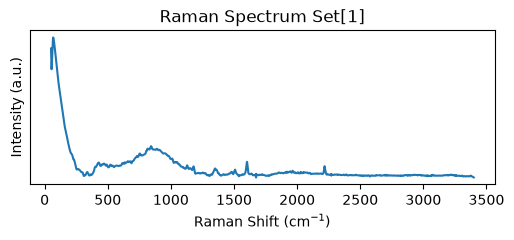

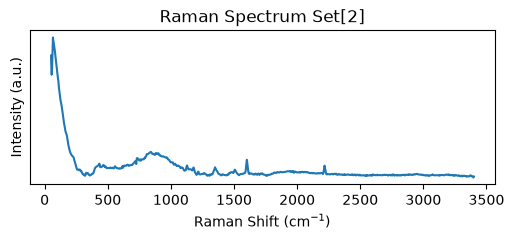

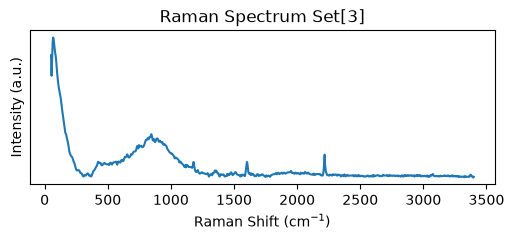

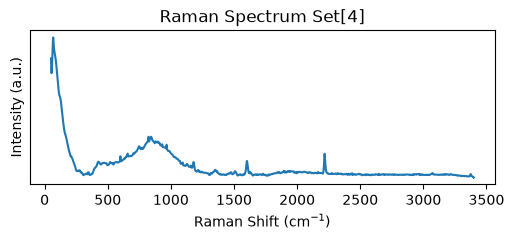

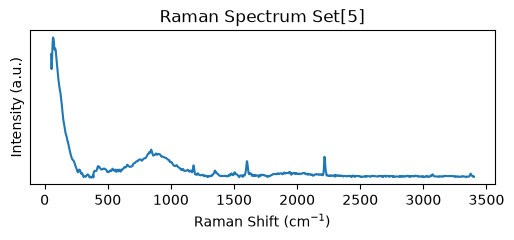

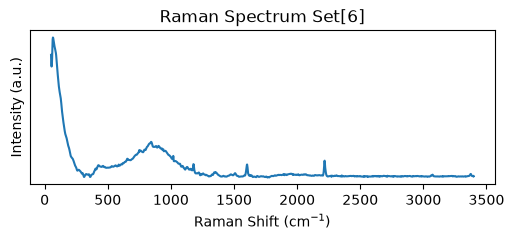

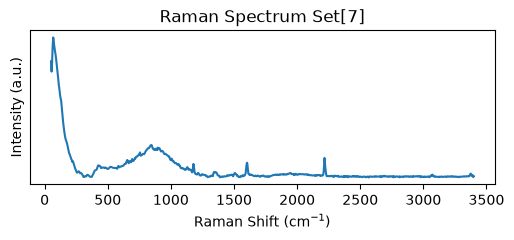

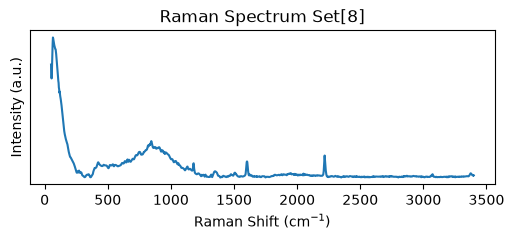

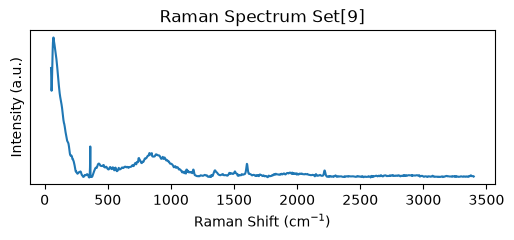

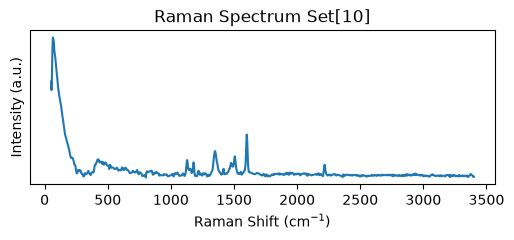

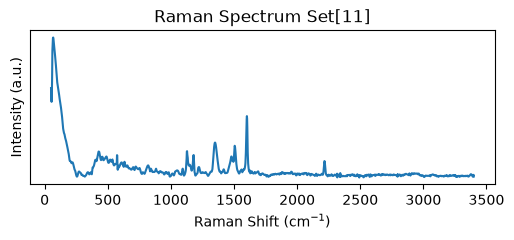

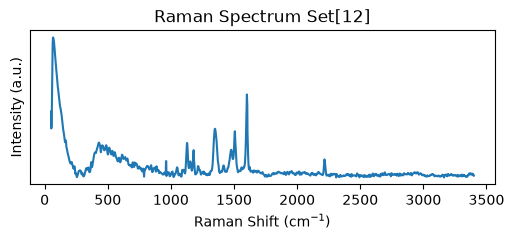

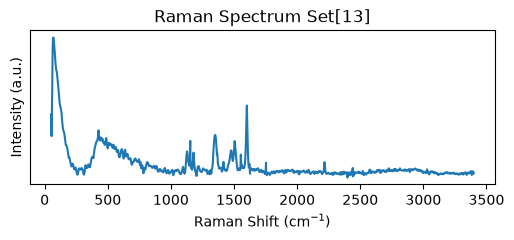

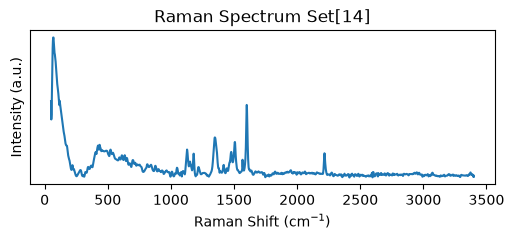

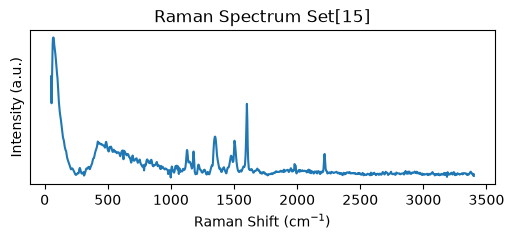

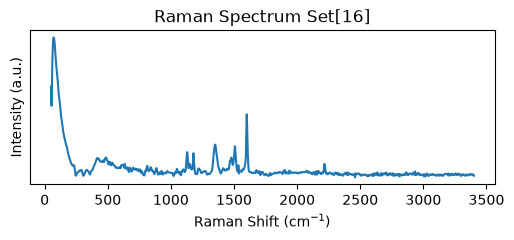

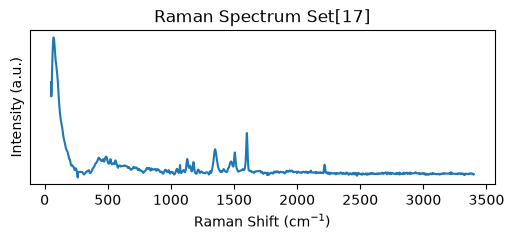

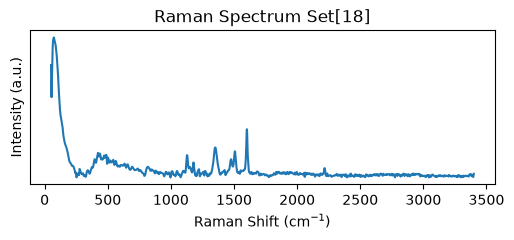

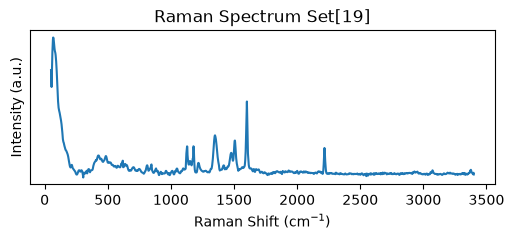

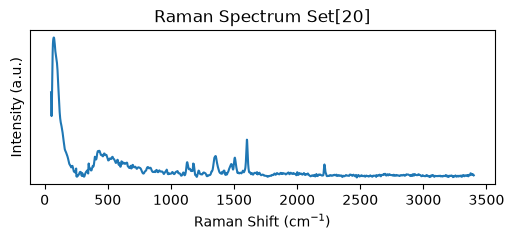

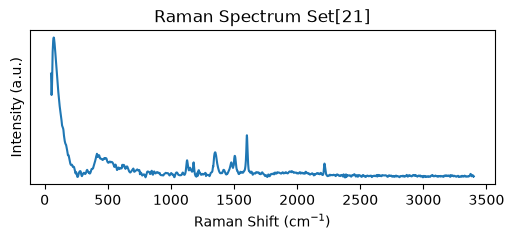

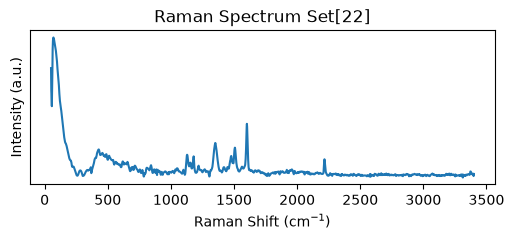

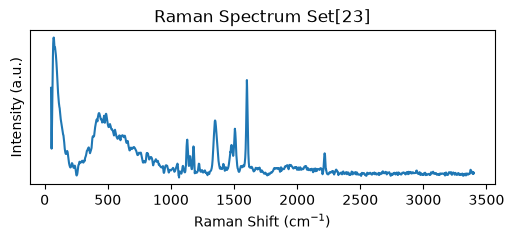

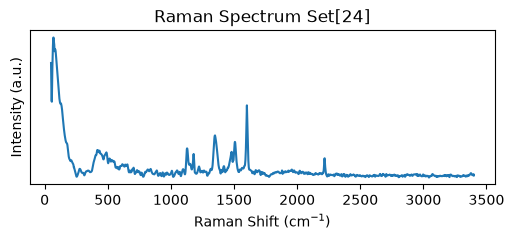

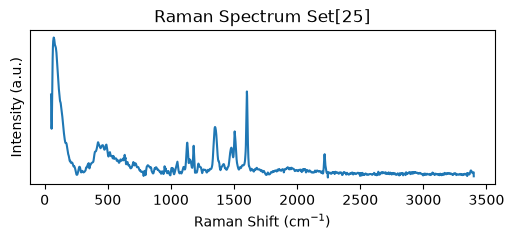

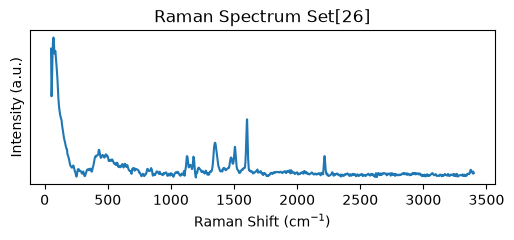

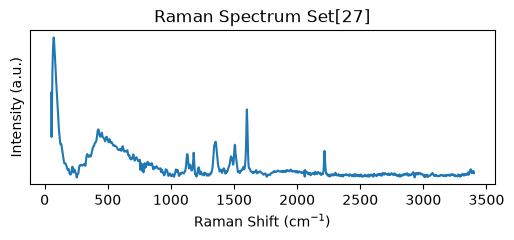

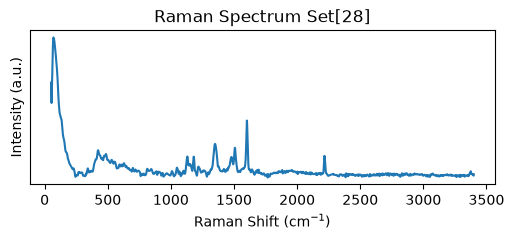

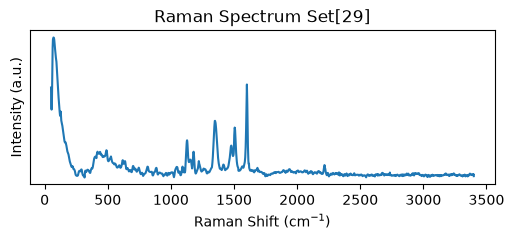

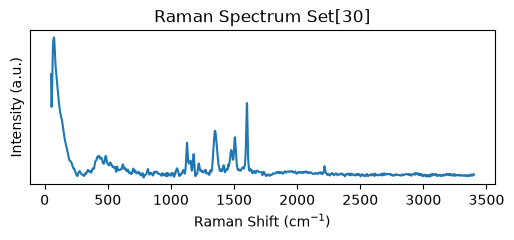

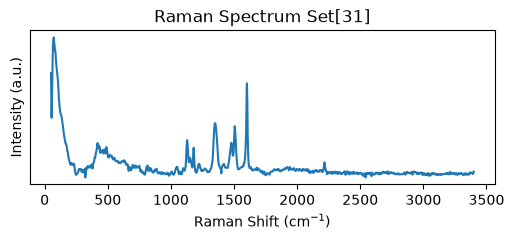

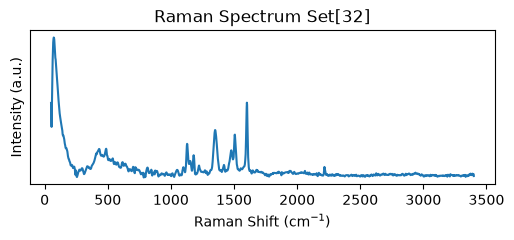

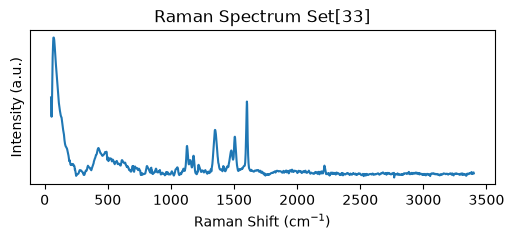

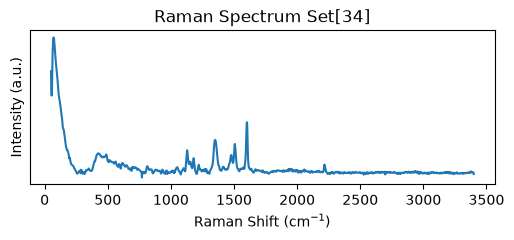

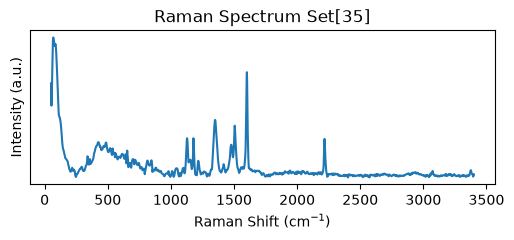

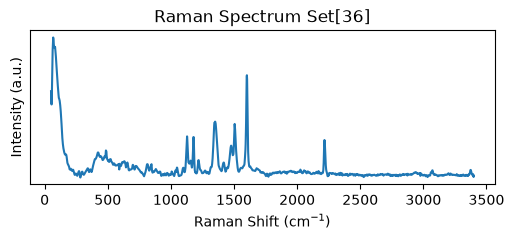

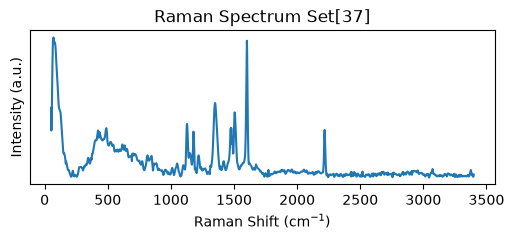

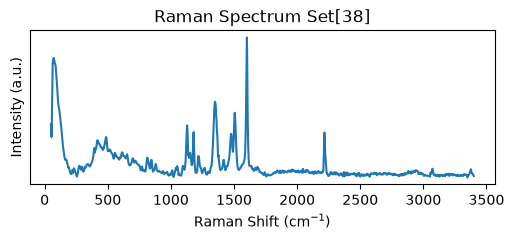

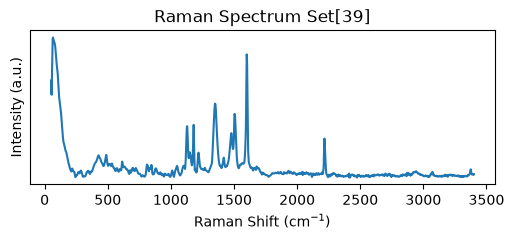

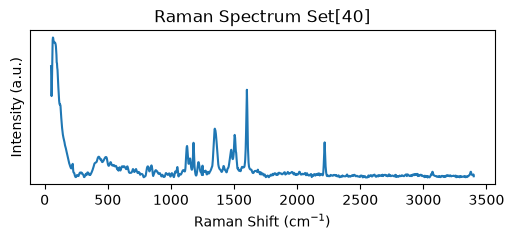

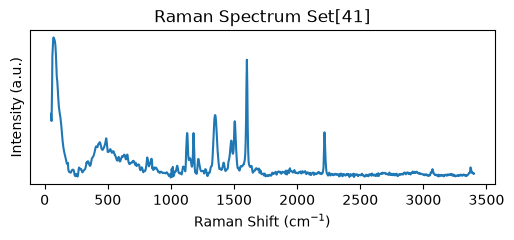

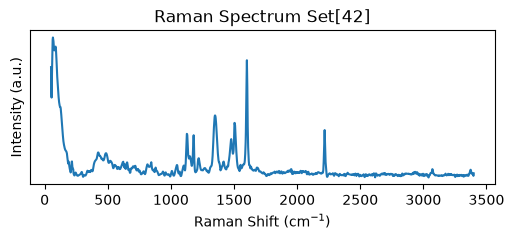

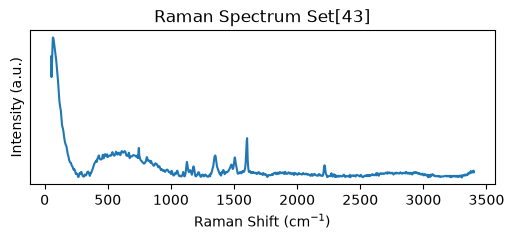

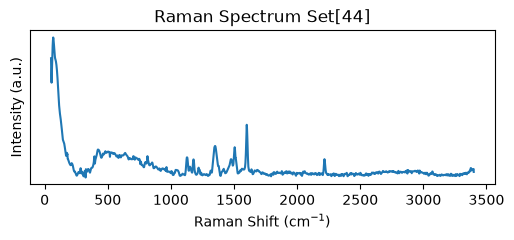

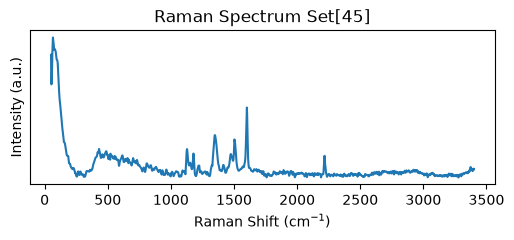

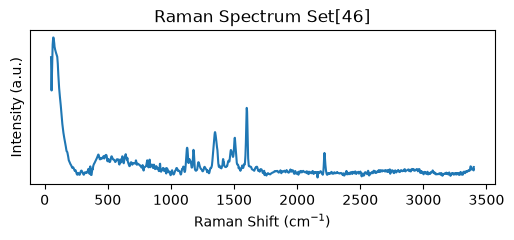

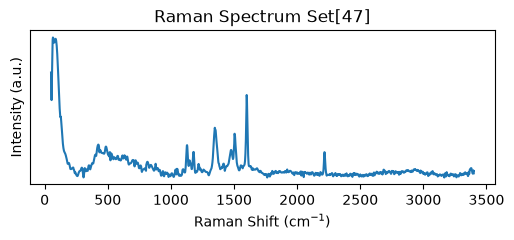

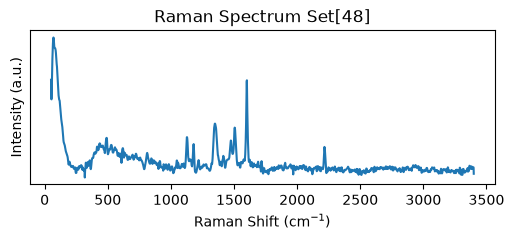

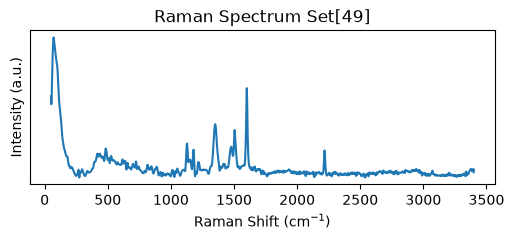

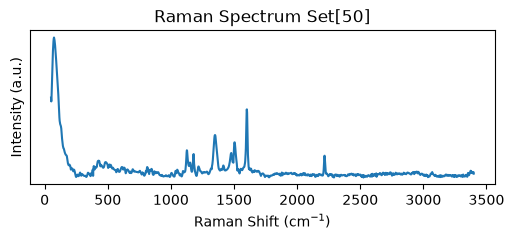

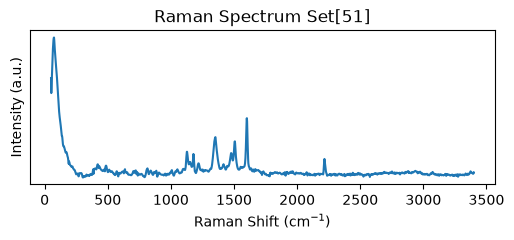

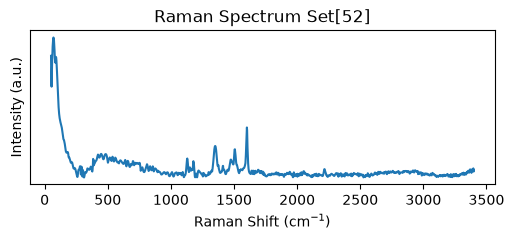

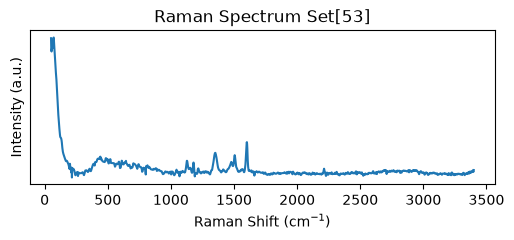

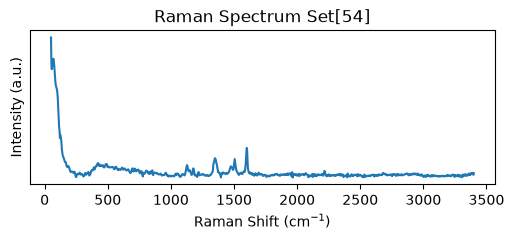

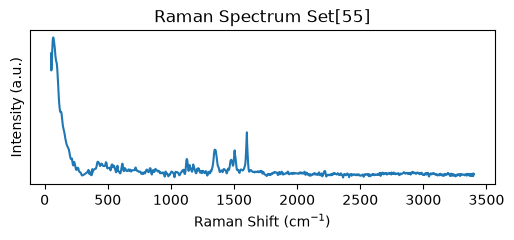

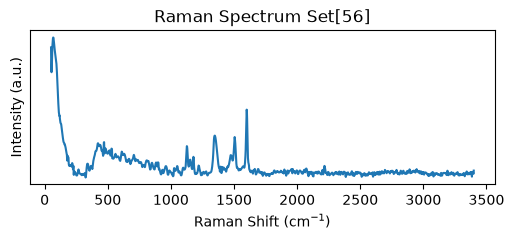

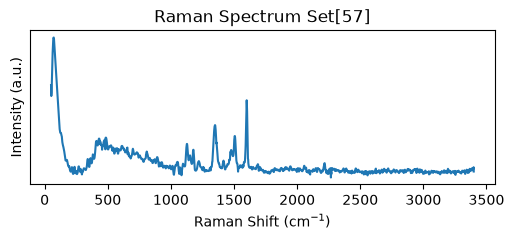

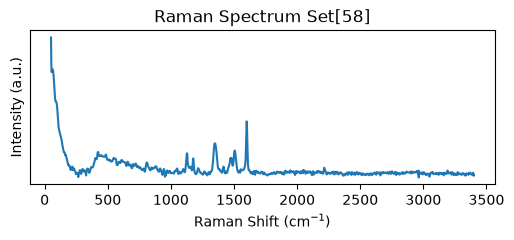

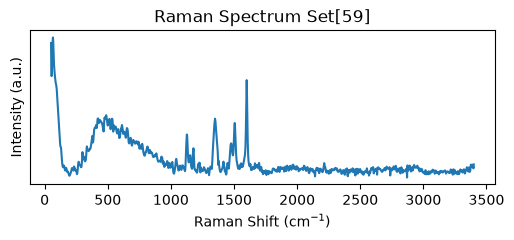

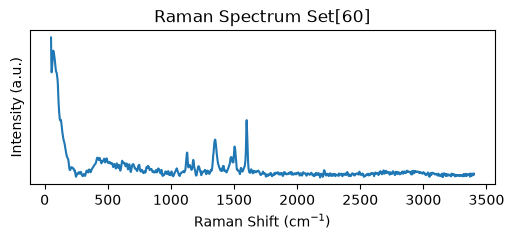

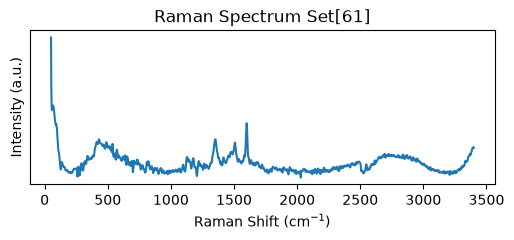

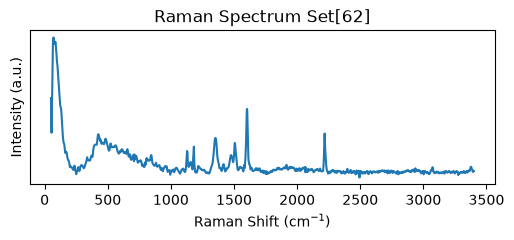

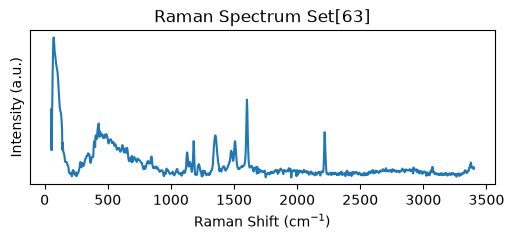

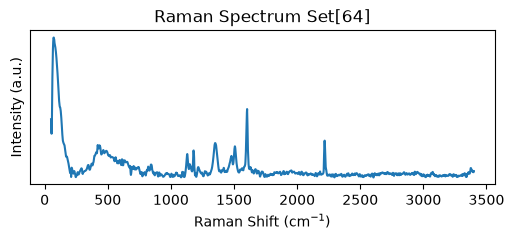

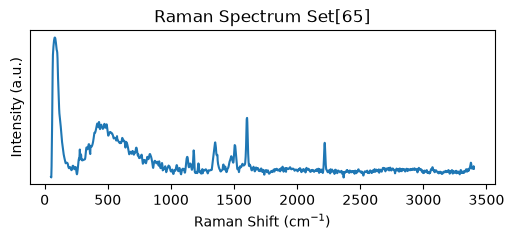

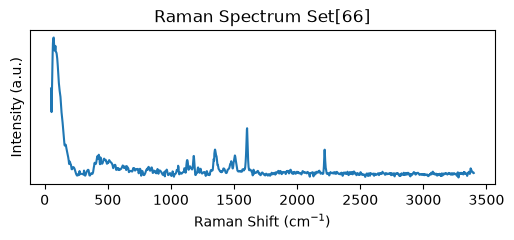

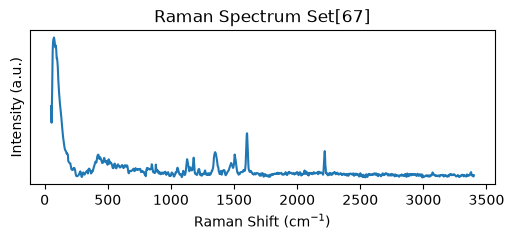

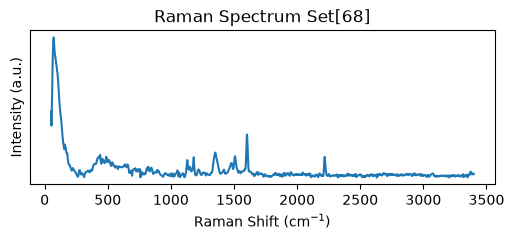

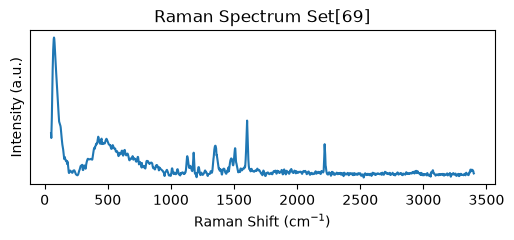

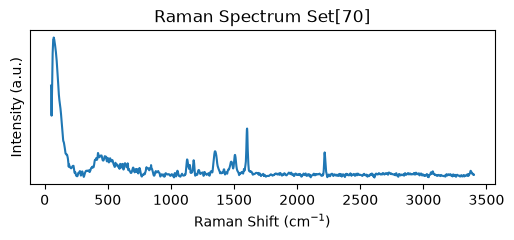

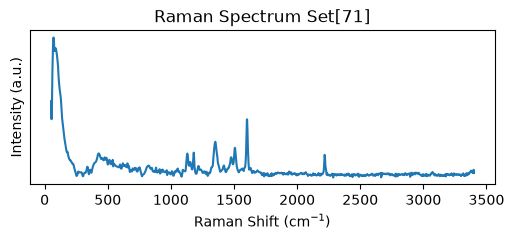

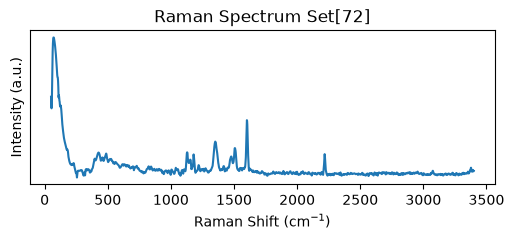

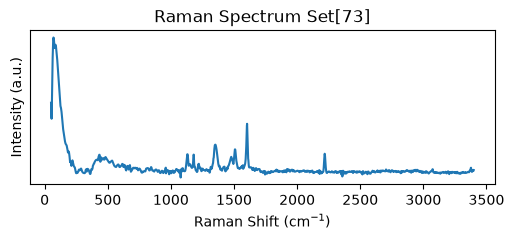

In [15]:
serial_plotter(dataset_dye)

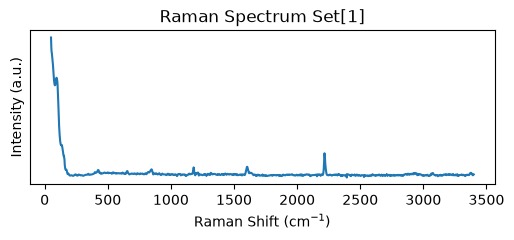

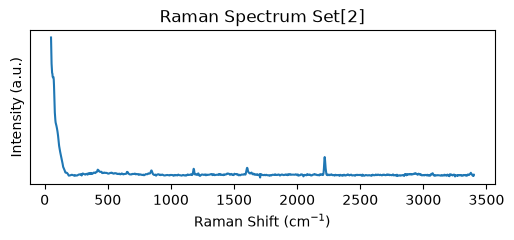

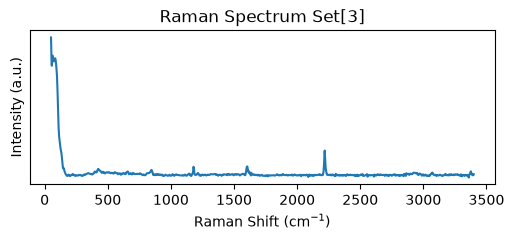

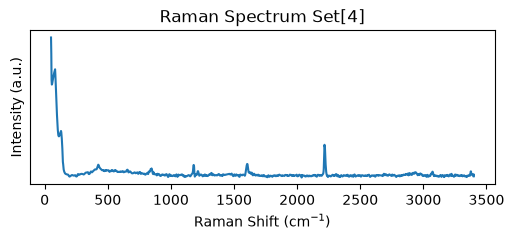

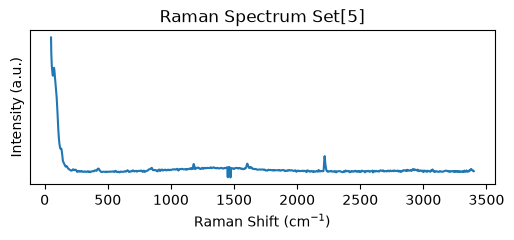

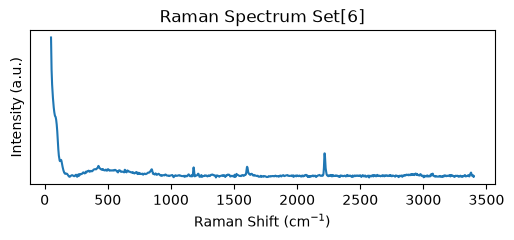

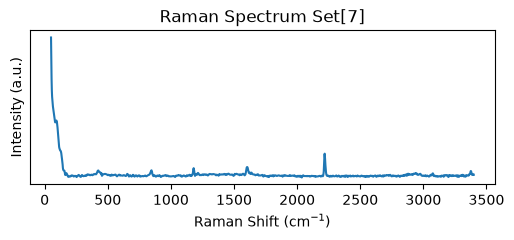

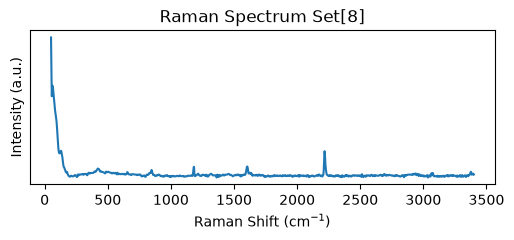

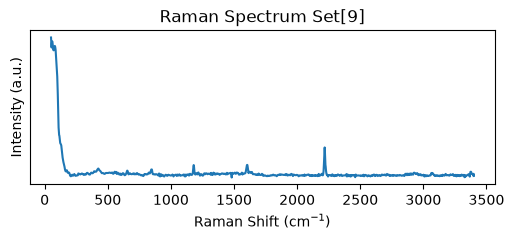

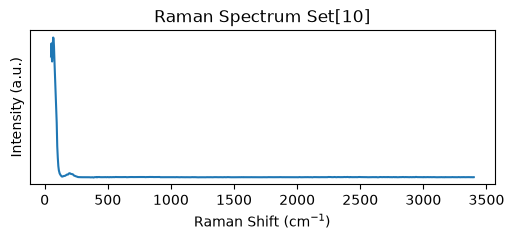

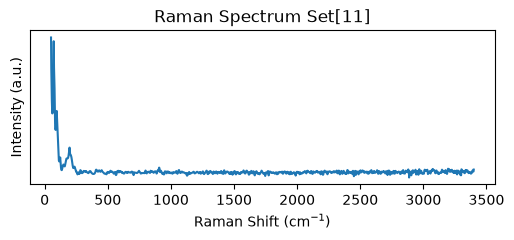

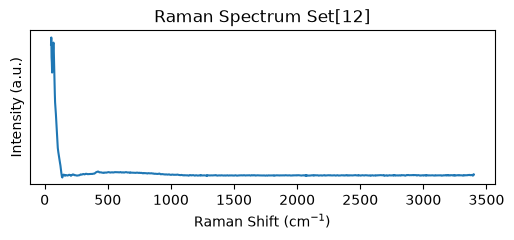

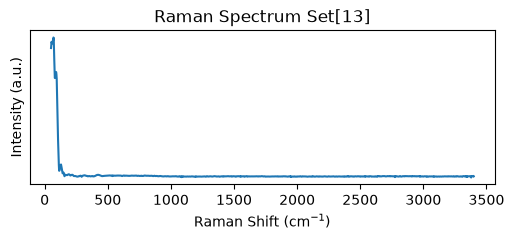

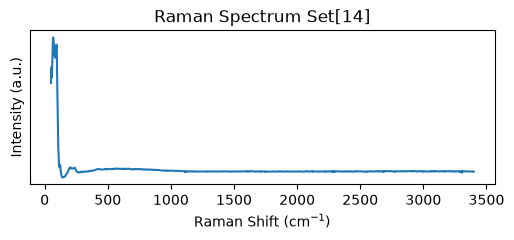

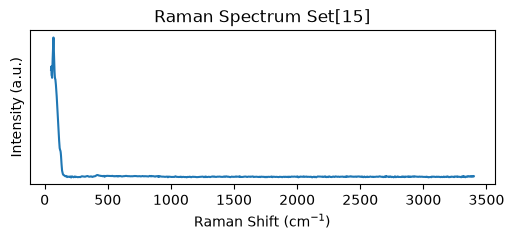

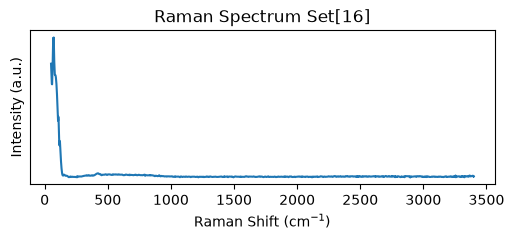

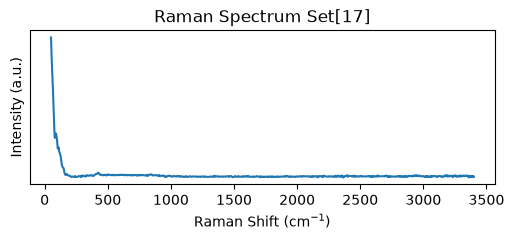

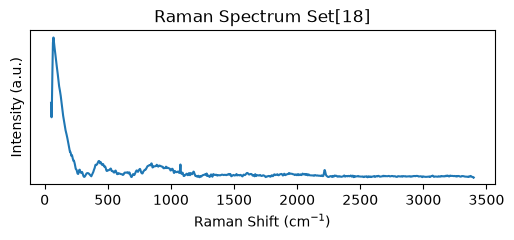

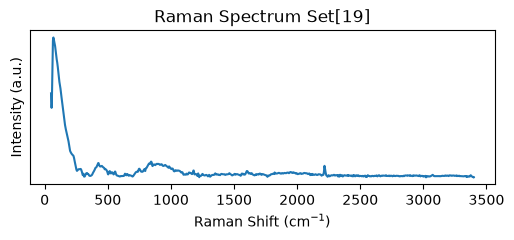

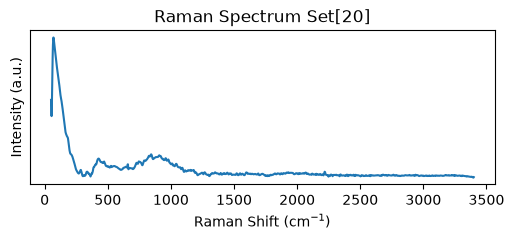

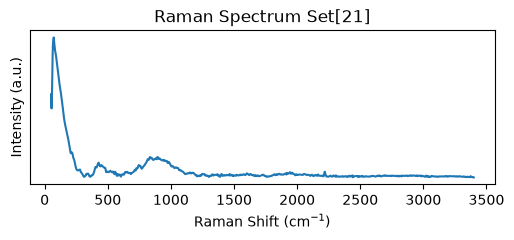

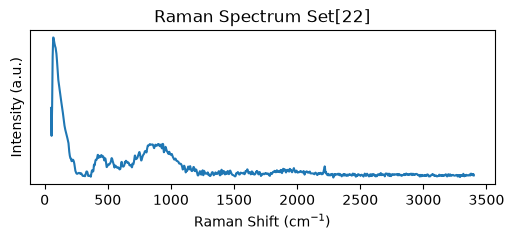

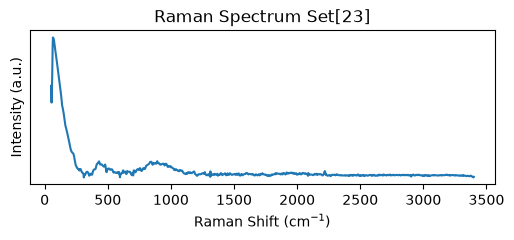

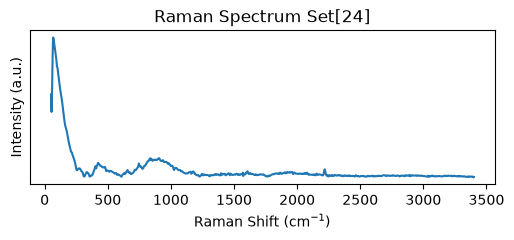

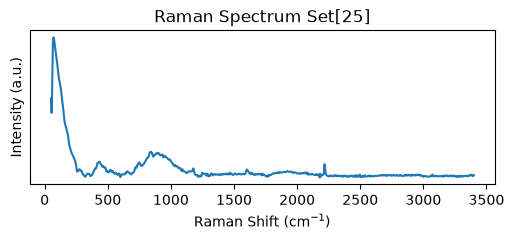

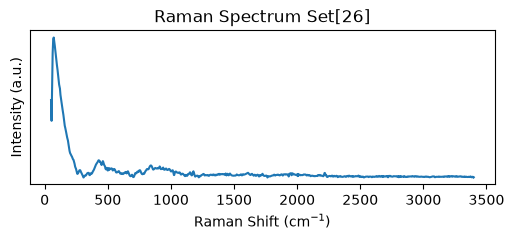

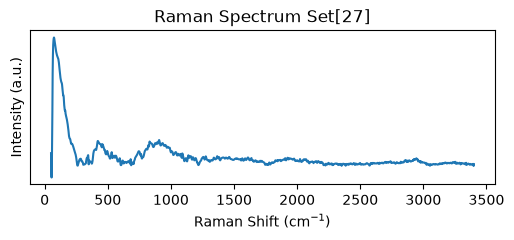

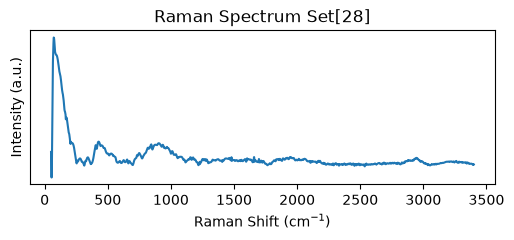

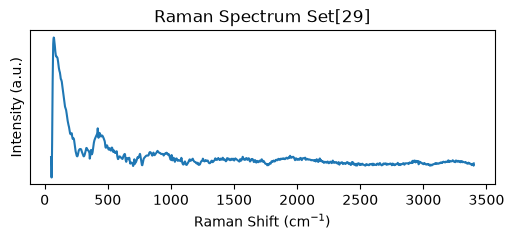

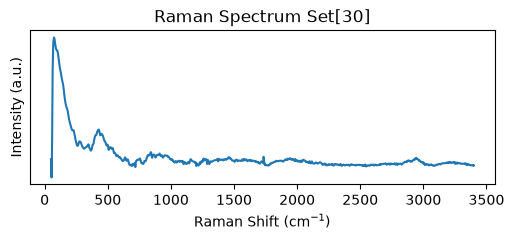

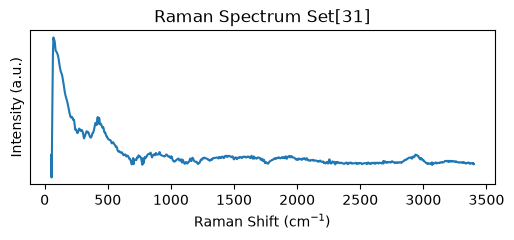

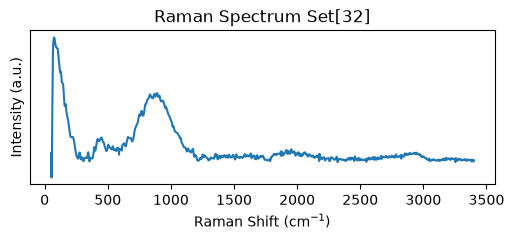

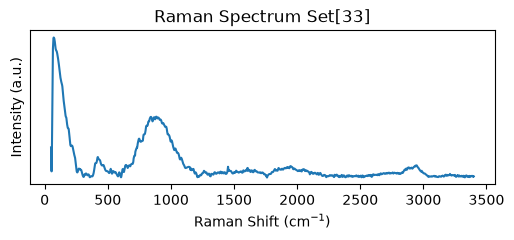

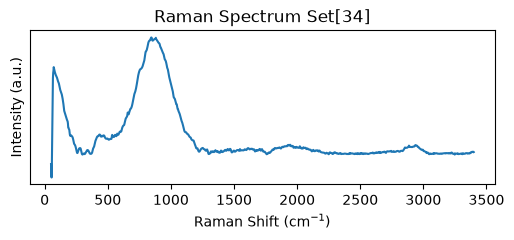

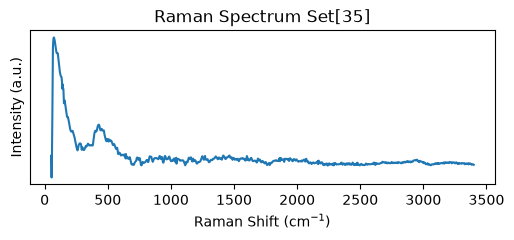

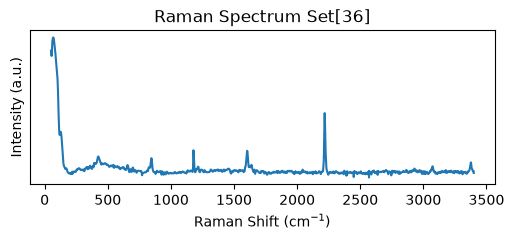

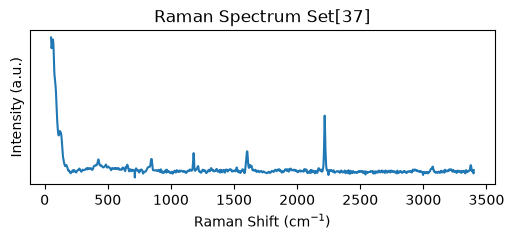

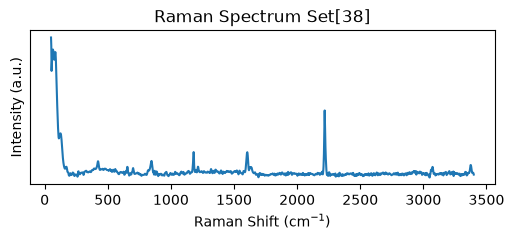

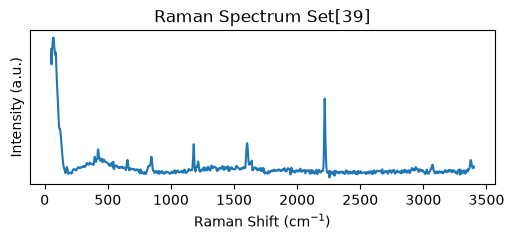

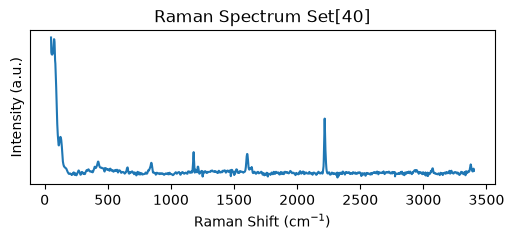

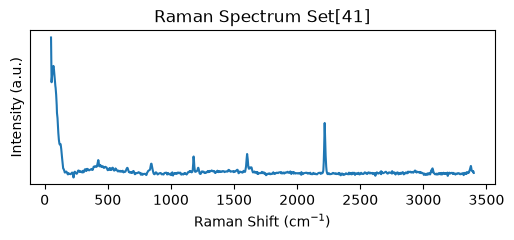

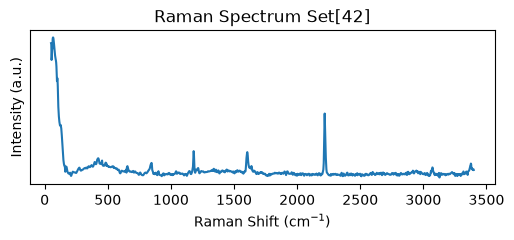

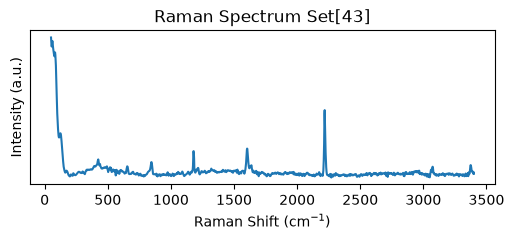

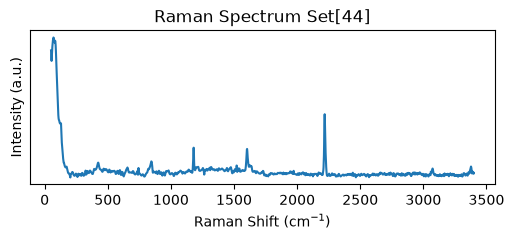

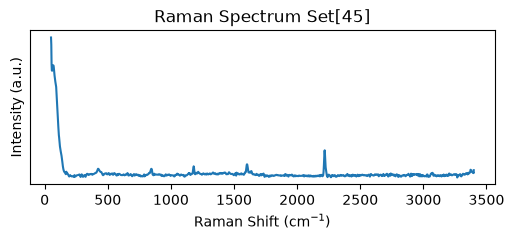

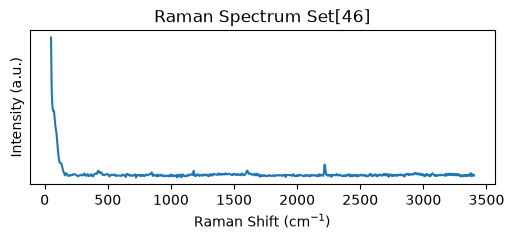

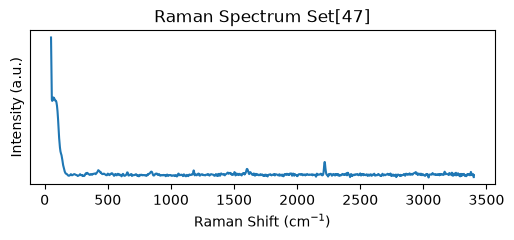

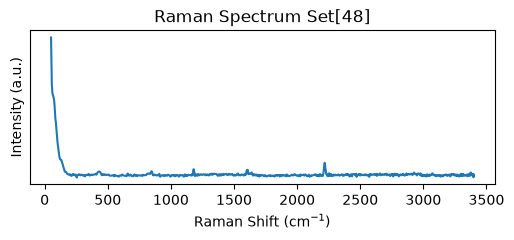

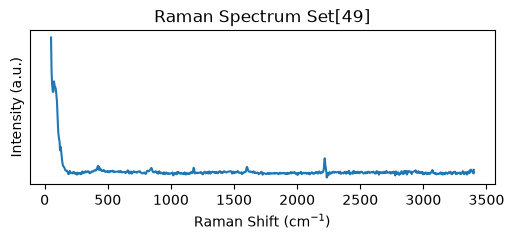

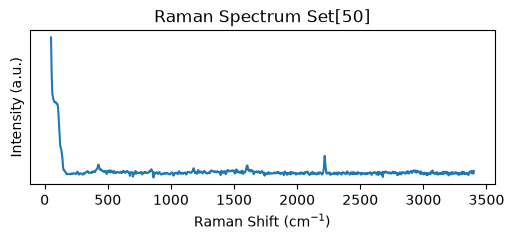

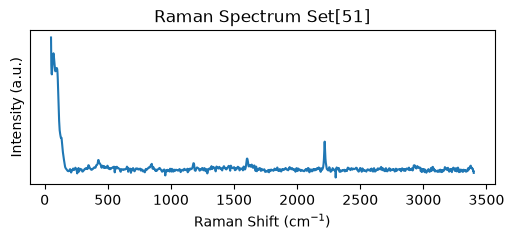

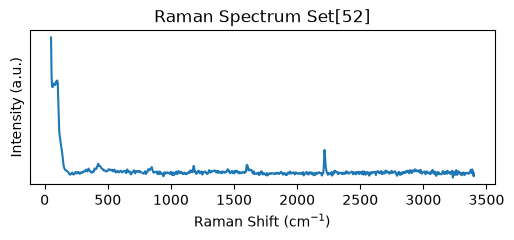

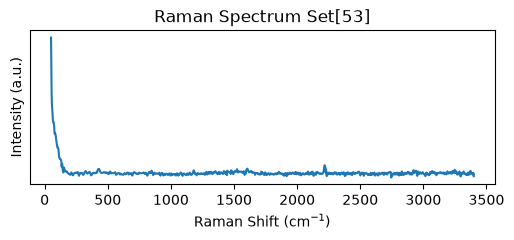

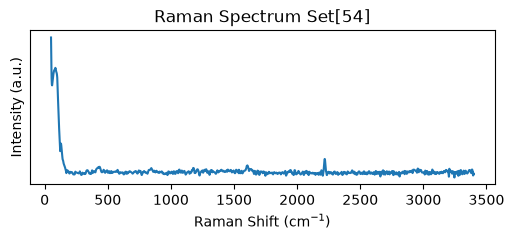

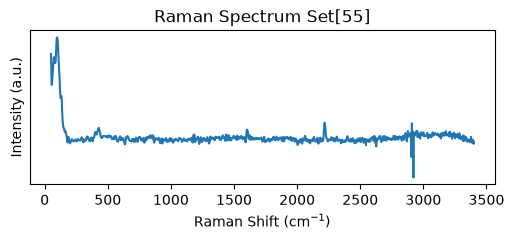

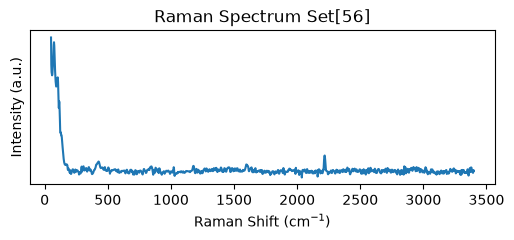

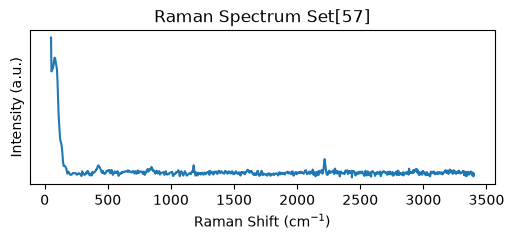

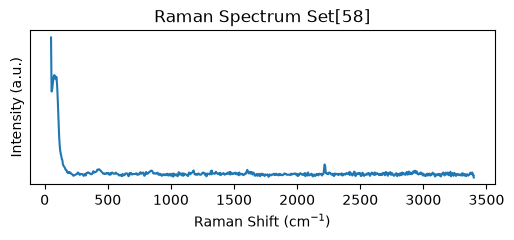

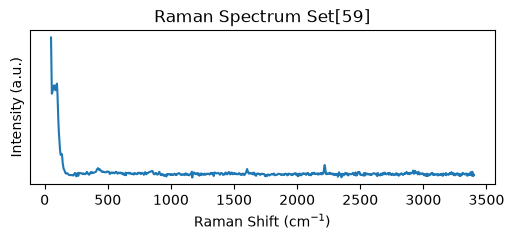

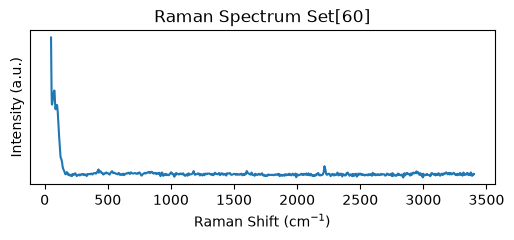

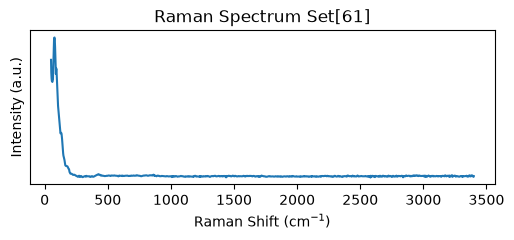

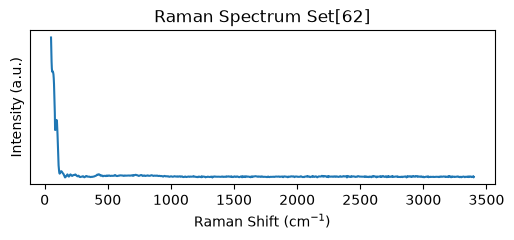

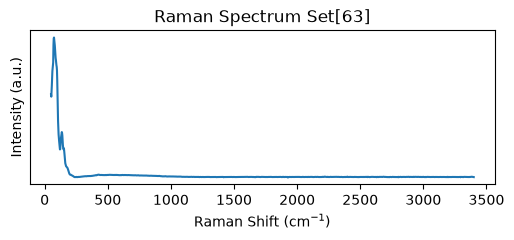

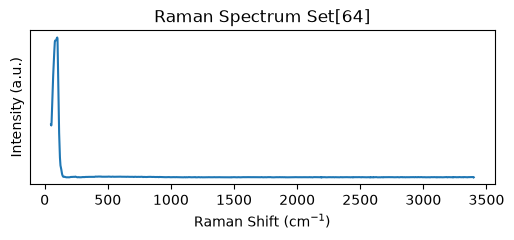

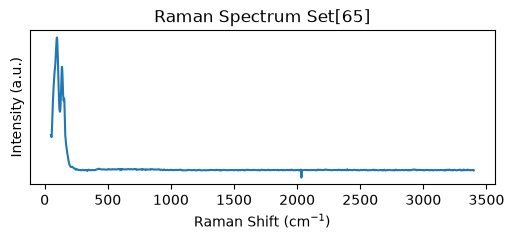

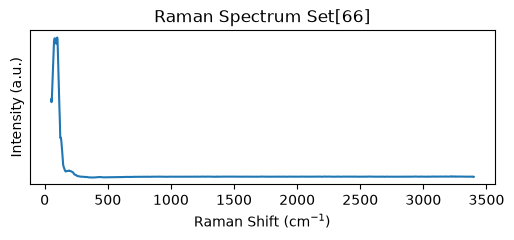

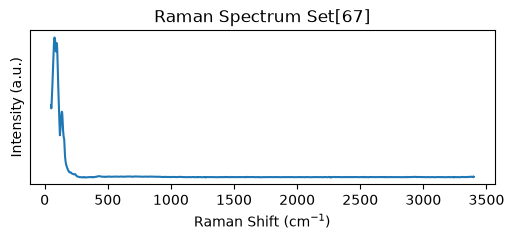

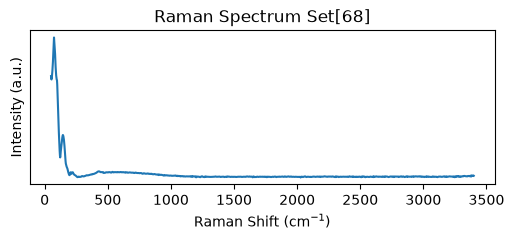

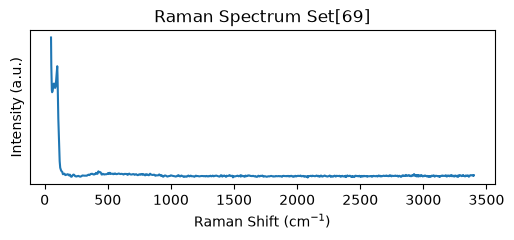

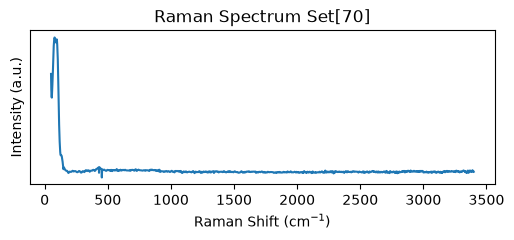

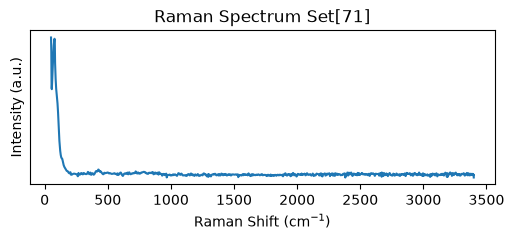

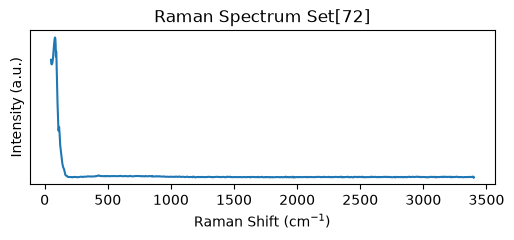

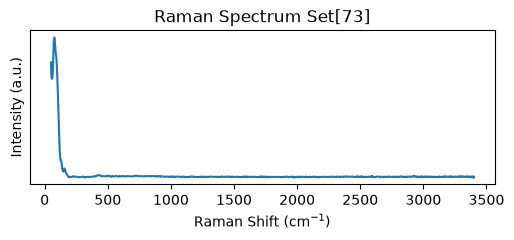

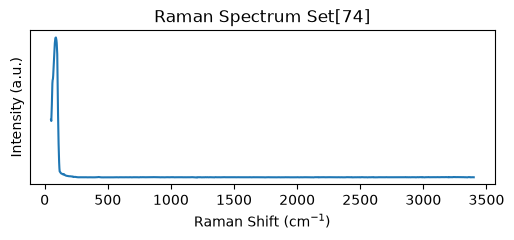

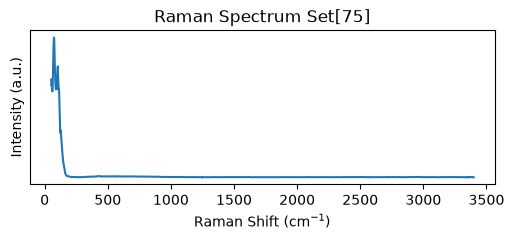

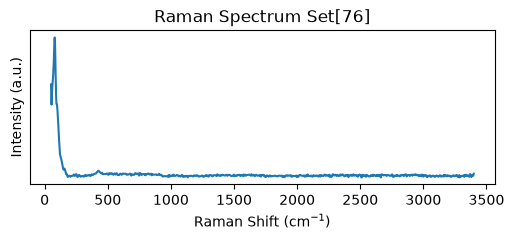

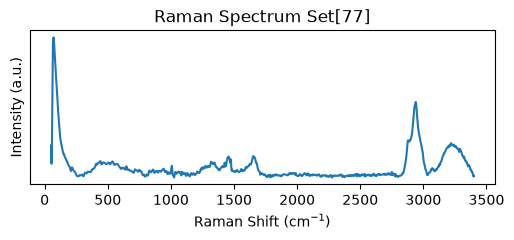

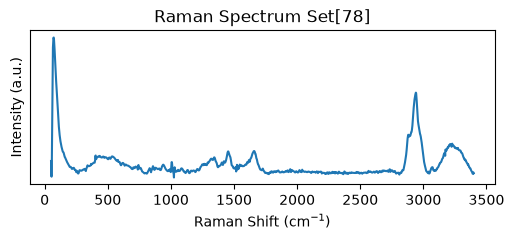

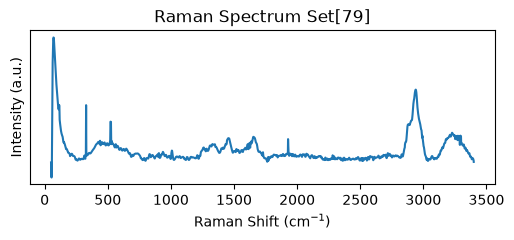

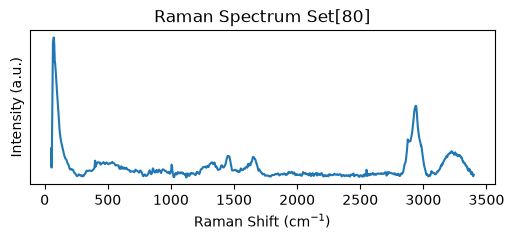

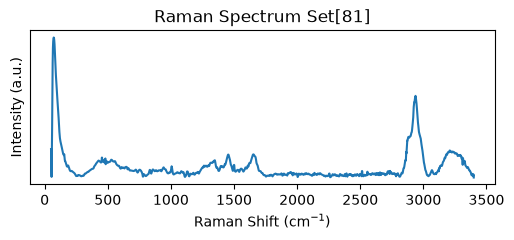

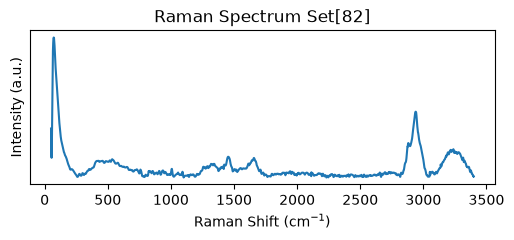

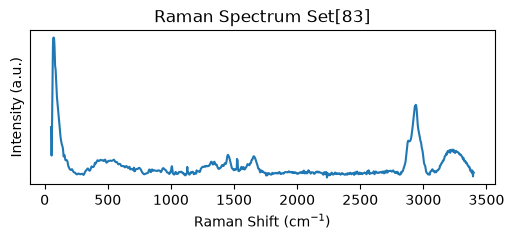

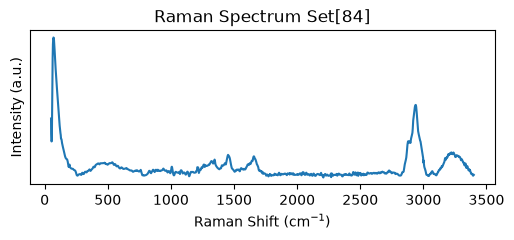

In [16]:
serial_plotter(dataset_wo)

# Produce A List of Selectable Dataset to Train With